In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

In [2]:
SF_20 = np.load('../Data/SAXS/Structure Factors/Bridge_20_SF.npy')
SF_40 = np.load('../Data/SAXS/Structure Factors/Bridge_40_SF.npy')
SF_80 = np.load('../Data/SAXS/Structure Factors/Bridge_80_SF.npy')
SF_CP = np.load('../Data/SAXS/Structure Factors/cp_agg_SF.npy')

In [3]:
simulation_80 = np.load('../Data/Simulations/Bridge 80 Structure Factor/Sample_44_Best/Density_0.005_U_0_7.46293_r0_2.86209_n_30.0_m_1.0/scattering_data/structure_factor-5.npy')
simulation_40 = np.load('../Data/Simulations/Bridge 40 Structure Factor/Sample_67_Best/Density_0.005_U_0_81.42227_r0_2.42687_n_21.78117_m_1.0/scattering_data/structure_factor-5.npy')
simulation_20 = np.load('../Data/Simulations/Bridge 20 Structure Factor/Sample_52_good/Density_0.005_U_0_46.95262_r0_2.25_n_1.0_m_20.89932/scattering_data/structure_factor-5.npy')
CP_agg = np.load('../Data/Simulations/Close Packed Structure Factor/Sample_33_Best_Sample/Density_0.0005_U_0_150.0_r0_1.24814_n_8.4517_m_28.92052/scattering_data/structure_factor-5.npy')

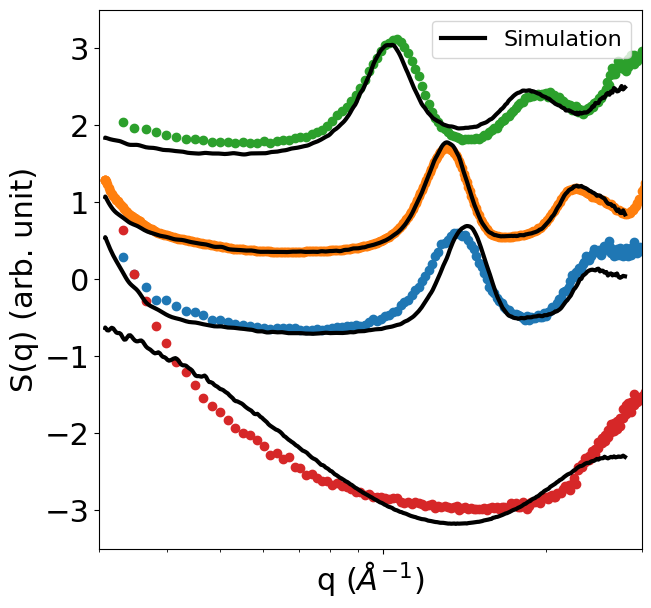

In [4]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(SF_20[:,0], SF_20[:,1]-1, color = 'C0') #, label = '20 Bridge')
plt.scatter(SF_40[:,0], SF_40[:,1]/1.3+0.25, color = 'C1') #, label = '40 Bridge')
plt.scatter(SF_80[:,0], SF_80[:,1]+1.35, color = 'C2') #, label = '80 Bridge')
plt.scatter(SF_CP[:,0], SF_CP[:,1]-3.5, color = 'C3') #, label = 'Close Packed Agg.')

plt.plot(simulation_20[:-160,0], simulation_20[:-160,1]/1.6-0.8, linewidth = 3, color='k', label = 'Simulation')
plt.plot(simulation_40[:-160,0], simulation_40[:-160,1]/1.3+0.25, linewidth = 3, color='k')
plt.plot(simulation_80[:-160,0], simulation_80[:-160,1]/1.3+1.50, linewidth = 3, color='k')
plt.plot(CP_agg[:-160,0], CP_agg[:-160,1]-3.5, linewidth = 3, color='k')

plt.xlim([0.003, 0.03])
plt.ylim([-3.5, 3.5])
#plt.yscale('log')
plt.ylabel('S(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
#ax.set_yticks([])
ax.set_xticks([0.01])
ax.set_xticklabels(['0.01'])
plt.xscale('log')
plt.legend(fontsize=16)
#plt.legend(loc='center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=14)
#plt.savefig('../Figures/Best_SF_3.png', dpi=600, bbox_inches="tight")

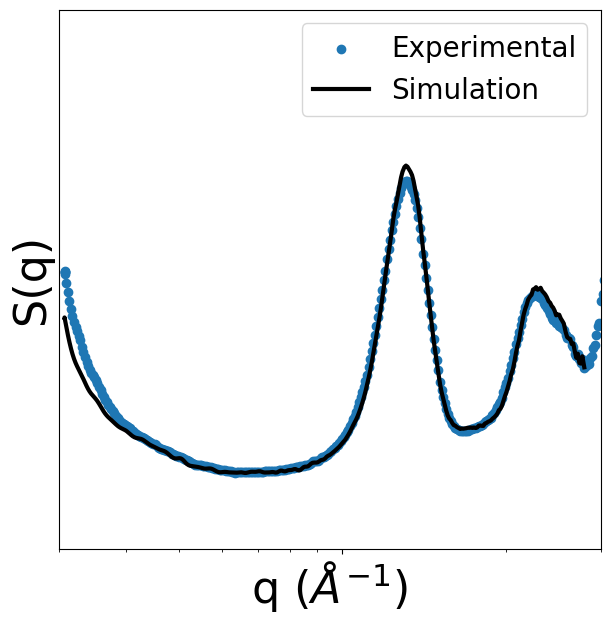

In [5]:
fig, ax = plt.subplots(figsize=(7,7))
#plt.scatter(SF_20[:,0], SF_20[:,1]-1, color = 'C0') #, label = '20 Bridge')
plt.scatter(SF_40[:,0], SF_40[:,1]/1.3+0.25, color = 'C0', label = 'Experimental')
#plt.scatter(SF_80[:,0], SF_80[:,1]+1.35, color = 'C2') #, label = '80 Bridge')
#plt.scatter(SF_CP[:,0], SF_CP[:,1]-3.5, color = 'C3') #, label = 'Close Packed Agg.')

#plt.plot(simulation_20[:-160,0], simulation_20[:-160,1]/1.6-0.8, linewidth = 5, color='k')
plt.plot(simulation_40[:-160,0], simulation_40[:-160,1]/1.3+0.25, linewidth = 3, color='k', label='Simulation')
#plt.plot(simulation_80[:-160,0], simulation_80[:-160,1]/1.3+1.50, linewidth = 3, color='k')
#plt.plot(CP_agg[:-160,0], CP_agg[:-160,1]-3.5, linewidth = 3, color='k')

plt.xlim([0.003, 0.03])
plt.ylim([-0.0, 2.5])
#plt.yscale('log')
plt.ylabel('S(q)', fontsize=32)
plt.xlabel('q ($\\AA^{-1}$)', fontsize=32)
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
ax.set_yticks([])
ax.set_xticks([0.01])
ax.set_xticklabels(['0.01'])
plt.xscale('log')
plt.legend(fontsize=20)
#plt.legend(loc='center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=14)
#plt.savefig('../Figures/struc_toc_image.png', dpi=600, bbox_inches="tight")

In [6]:
def extract_input_params(path):
    filenames = sorted(os.listdir(path))
    for i in range(len(filenames)):
        if len(filenames[i]) == 8:
            new_name = filenames[i][0:7] + '0' + filenames[i][-1]
            os.rename(path + filenames[i], path + '/' + new_name)
    for i in range(len(filenames)):
        #filenames2 = sorted(os.listdir(path + filenames[i]))[1]
        filenames3 = sorted(os.listdir(path + filenames[i]))[-1]
        filenames4 = sorted(os.listdir(path + filenames[i]))[-2]
        try:
            input_params = pd.read_csv(path + '/' + filenames[i] + '/' + filenames3).values.reshape(1,-1)
            score = pd.read_csv(path + '/' + filenames[i] + '/' + filenames4).values[0][0]
            if i == 0:
                input_params_all = input_params
            else:
                input_params_all = np.vstack((input_params_all, input_params))
        except:
            print()
    return input_params_all

In [7]:
path = '../Data/Simulations/Close Packed Structure Factor/'
input_params_cp = extract_input_params(path)
path = '../Data/Simulations/Bridge 20 Structure Factor/'
input_params_20 = extract_input_params(path)
path = '../Data/Simulations/Bridge 40 Structure Factor/'
input_params_40 = extract_input_params(path)
path = '../Data/Simulations/Bridge 80 Structure Factor/'
input_params_80 = extract_input_params(path)

In [8]:
def modified_LJ(r, rmin, rmax, U_0, n, m, r0):
    U = U_0/(n - m) * (m*(r0/r)**n - n*(r0/r)**m)
    F = U_0*m*n*((r0/r)**n - (r0/r)**m)/((n-m)*r)
    return U, F
r0 = 1
rmin = 0.75*r0
rmax = 5
# m = 12
width = 1000
# U_0 = 100
# n = 16.98
r_vals = np.linspace(rmin, rmax, width)
# U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)

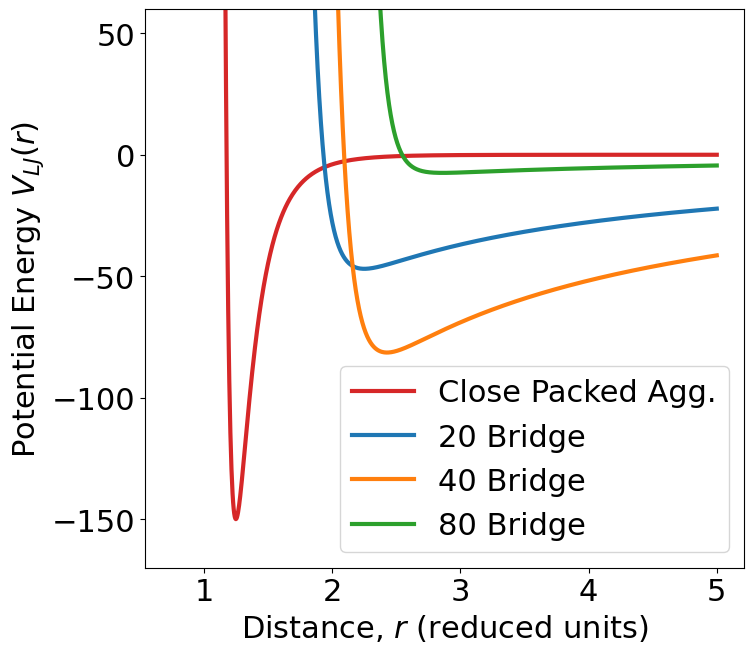

In [10]:
# Plots all the potentials together 
fig, ax = plt.subplots(figsize=(8,7))
params = input_params_cp[-1, :]
U_0 = params[1]
n = params[3]
r0 = params[2]
m = params[4]
U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)
plt.plot(r_vals, U, label='Close Packed Agg.', linewidth = 3, color='C3')

params = input_params_20[-1, :]
U_0 = params[1]
n = params[3]
r0 = params[2]
m = params[4]
U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)
plt.plot(r_vals, U, label='20 Bridge', linewidth = 3, color='C0')

params = input_params_40[-1, :]
U_0 = params[1]
n = params[3]
r0 = params[2]
m = params[4]
U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)
plt.plot(r_vals, U, label='40 Bridge', linewidth = 3, color='C1')

params = input_params_80[-1, :]
U_0 = params[1]
n = params[3]
r0 = params[2]
m = params[4]
U, F = modified_LJ(r_vals, rmin, rmax, U_0, n, m, r0)
plt.plot(r_vals, U, label='80 Bridge', linewidth = 3, color='C2')


plt.xlabel("r")
plt.ylabel("Potential Energy $V_{LJ}(r)$")
plt.xlabel('Distance, $r$ (reduced units)')
plt.ylim([-170, 60])
plt.tight_layout()
#plt.title('Iteration ' + str(i))
plt.legend()
plt.savefig("../Figures/potential_plot_all_best.png", dpi=600, bbox_inches="tight")   
